In [30]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
def generate_noise_level_vs_dt_matrix(rhs, x0, t_span, noise_levels, dts,
                                      generate_prediction, generate_more_derivatives, threshold=0.05):
    # we will return data as a 2d matrix of dictionaries
    # results[row][col] will be a dictionary of results for the test with dt=dts[row] and noise_level=noise_levels[col]

    # initialize the data matrix with None entries
    results = [[None for _ in range(len(noise_levels))] for _ in range(len(dts))]

    for i, dt in enumerate(dts):
        print(f"dt: {dt}")

        for j, noise_level in enumerate(tqdm(noise_levels)):
            result = {}

            # generate evaluation time points
            t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
            result["t_eval"] = t_eval

            # generate training data
            x_train = generate_training_data(rhs, x0, t_eval)
            result["x_train"] = x_train
            
            # generate noisy data
            x_train_noisy = add_noise_to_data(x_train, noise_level)
            result["x_train_noisy"] = x_train_noisy

            # generate the derivative of the noisy data using finite difference
            x_dot_finite_difference = dxdt_finite_difference(x_train_noisy, t_eval)
            result["x_dot_finite_difference"] = x_dot_finite_difference

            # generate the true derivative of the data
            # this is only used for comparison and is not used in the SINDy model
            x_dot_true = rhs(0, x_train)
            result["x_dot_true"] = x_dot_true

            # generate different derivative approximations if needed
            if generate_more_derivatives is True:
                x_dot_poly_fit = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=11)
                result['x_dot_poly_fit'] = x_dot_poly_fit
            
            # create and fit a SINDy model
            model = SINDyModel(n_state_vars=len(x0), threshold=threshold, poly_order=5)
            model.fit(x_train_noisy, x_dot_finite_difference)
            result["model"] = model

            # generate the model prediction if needed
            if generate_prediction is True:
                x_pred = generate_model_prediction(model, x0, t_eval)
                result["x_pred"] = x_pred
            
            # store the data entry
            results[i][j] = result
        
    return results

In [32]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

noise_levels = np.logspace(-3, 0, 10).tolist()
dts = np.logspace(-2, 0, 11).tolist()

results = generate_noise_level_vs_dt_matrix(
    rhs=lotka_volterra_rhs,
    x0=(10, 5),
    t_span=(0, 50),
    noise_levels=noise_levels,
    dts=dts,
    generate_prediction=True,
    generate_more_derivatives=False,
)

dt: 0.01


 70%|███████   | 7/10 [00:04<00:01,  1.71it/s]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\src\SINDyModel.py:142: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
100%|██████████| 10/10 [00:08<00:00,  1.21it/s]


dt: 0.015848931924611134


100%|██████████| 10/10 [00:07<00:00,  1.28it/s]


dt: 0.025118864315095794


...

 70%|███████   | 7/10 [00:12<00:11,  3.67s/it]

timeout occurred


c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
100%|██████████| 10/10 [00:14<00:00,  1.45s/it]


dt: 1.0


100%|██████████| 10/10 [00:11<00:00,  1.19s/it]


In [33]:
# make labels for use in the following heatmaps
xticklabels = [f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)]
yticklabels = [f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]]

In [34]:
# make a matrix of the relative coefficient errors

true_coeffs = generate_lotka_volterra_true_coefficients(1, 0.1, 1.5, 0.75)

rce_mtx = np.zeros((len(dts), len(noise_levels)))

for i in range(len(dts)):
    for j in range(len(noise_levels)):
        model = results[i][j]["model"]
        rce = relative_coefficient_error(true_coeffs, model.Xi)
        rce_mtx[i, j] = rce

# flip the matrices so that the smallest dt and noise level are in the bottom left corner
rce_mtx = rce_mtx[:, ::-1].T

In [35]:
# make a matrix of the relative trajectory errors

rte_mtx = np.zeros((len(dts), len(noise_levels)))

for i in range(len(dts)):
    for j in range(len(noise_levels)):
        x_train = results[i][j]["x_train"]
        x_pred = results[i][j]["x_pred"]

        # calculate the relative trajectory error
        # if the model prediction is "None", set the rte to np.nan
        if x_pred is None:
            rte = np.nan
        else:
            rte = relative_trajectory_error(x_train, x_pred)
        
        rte_mtx[i, j] = rte

# flip the matrices so that the smallest dt and noise level are in the bottom left corner
rte_mtx = rte_mtx[:, ::-1].T

[Text(0.5, 25.649999999999984, 'dt'),
 Text(59.64999999999999, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Trajectory Error')]

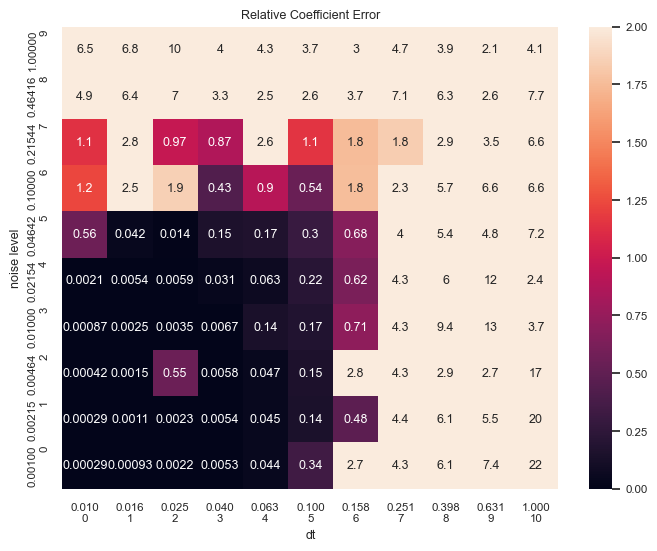

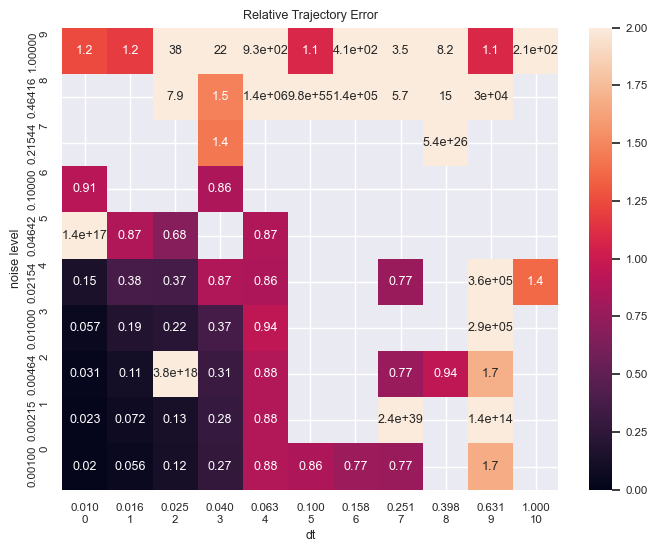

In [36]:
import seaborn as sns

sns.set_theme(font_scale=0.75)

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(rce_mtx, annot=True, xticklabels=xticklabels, yticklabels=yticklabels, vmin=0, vmax=2)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Coefficient Error")

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(rte_mtx, annot=True, xticklabels=xticklabels, yticklabels=yticklabels, vmin=0, vmax=2)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Trajectory Error")

### INTRESTING OBSERVATION: if the trajectory is shifted a tiny bit, it can result in huge errors

0.5930687631232853
x0' = + 0.98782 x0 + -0.10008 x0 x1 
x1' = + -1.47623 x1 + 0.74412 x0 x1 


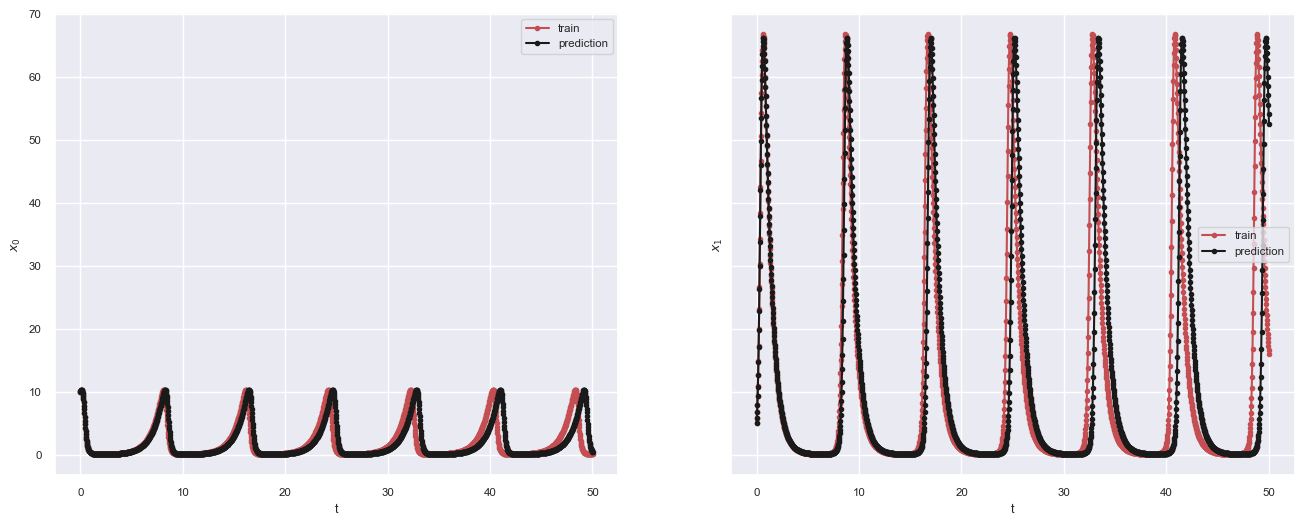

In [39]:
# set the indices of the data entry you'd like to explore
dt_idx = 2
noise_level_idx = 5

# extract the relevant data from the data entry
result = results[dt_idx][noise_level_idx]
t_eval = result['t_eval']
x_train = result['x_train']
x_pred = result['x_pred']

# relative absolute error
print(np.abs(x_train - x_pred).sum() / np.abs(x_train).sum())

# print the model
model = result['model']
model.print()

n_state_vars = x_train.shape[0]

# plot the training data and model prediction
fig, axs = plt.subplots(1, n_state_vars, figsize=(16, 6), sharex='col', sharey='row')

for sv in range(n_state_vars):
    # plot the col'th training state variable
    axs[sv].plot(t_eval, x_train[sv], "r.-", label="train")

    # plot the col'th state variable model prediction
    axs[sv].plot(t_eval, x_pred[sv], "k.-", label="prediction")

    # set labels
    axs[sv].set_xlabel("t")
    axs[sv].set_ylabel(f"$x_{sv}$")
    axs[sv].legend()

x0' = + 0.96367 x0 + -0.09688 x0 x1 
x1' = + -0.28382 x0 + -1.44047 x1 + 0.06314 x0^2 + 0.71699 x0 x1 


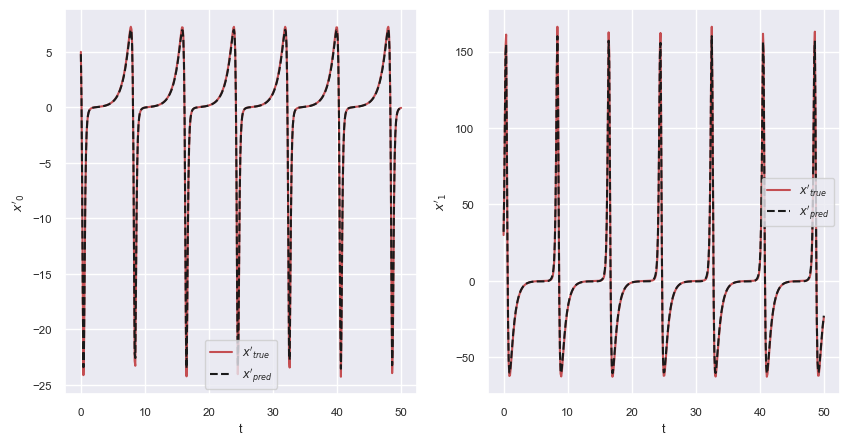

In [38]:
# look at how well SINDy can predict the derivative if we know the true trajectory

# set the indices of the data entry you'd like to explore
dt_idx = 5
noise_level_idx = 2

# extract the relevant data from the data entry
result = results[dt_idx][noise_level_idx]
t_eval = result['t_eval']
x_train = result['x_train']

x_dot_true = lotka_volterra_rhs(0, x_train)
x_dot_pred = result['model'].predict(x_train)

# print the model
model = result['model']
model.print()

n_state_vars = x_dot_true.shape[0]

# plot the training data and model prediction
fig, axs = plt.subplots(1, n_state_vars, figsize=(10, 5))

for sv in range(n_state_vars):
    axs[sv].plot(t_eval, x_dot_true[sv], "r", label="$x'_{true}$")
    axs[sv].plot(t_eval, x_dot_pred[sv], "k--", label="$x'_{pred}$")

    # set labels
    axs[sv].set_xlabel("t")
    axs[sv].set_ylabel(f"$x'_{sv}$")
    axs[sv].legend()